In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(84).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(44).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(245).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/6.jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(238).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(196).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(108).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(310).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image (5).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(186).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(29).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(140).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(224).jpg

In [4]:
!pip install pennylane

In [5]:
!pip install monai

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-07-17 06:53:45.403506: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752735225.465282     122 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752735225.484775     122 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device: cpu

--- Training QCNN + ResNet Model ---


Epoch 1, Val Loss: 1.0362, Val Acc: 0.6950


Epoch 2, Val Loss: 0.8842, Val Acc: 0.7488


Epoch 3, Val Loss: 0.9339, Val Acc: 0.7937


Epoch 4, Val Loss: 0.6933, Val Acc: 0.9938


Epoch 5, Val Loss: 0.6328, Val Acc: 0.9875
Accuracy: 0.6895
Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       1.00      0.14      0.24      1000
meningioma_tumor       0.58      0.99      0.73      1000
        no_tumor       0.66      1.00      0.79      1000
 pituitary_tumor       1.00      0.63      0.77      1000

        accuracy                           0.69      4000
       macro avg       0.81      0.69      0.63      4000
    weighted avg       0.81      0.69      0.63      4000



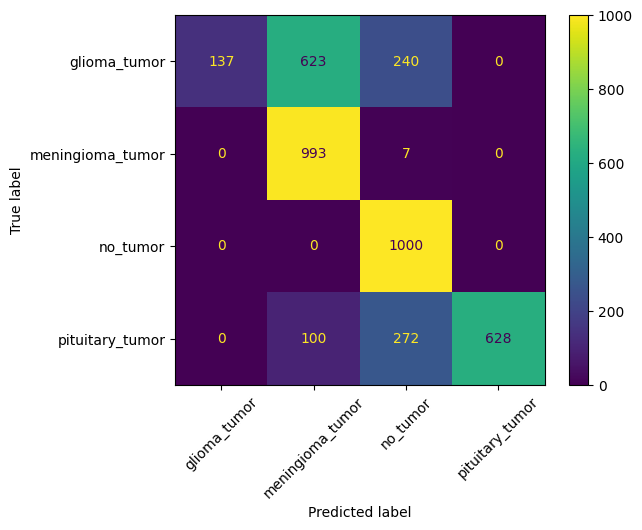

In [6]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from monai.transforms import ScaleIntensity
import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, random_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from PIL import Image
from tqdm import tqdm
import pennylane as qml
from pennylane import numpy as pnp

import warnings
warnings.filterwarnings("ignore")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load dataset
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
dataset_path_train = f'{path}/Training'
dataset_path_test = f'{path}/Testing'
img_size = (224, 224)
class_names = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
samples_per_class = 2000

# Transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

label_encoder = LabelEncoder()

def load_images_from_folder(folder, label, transform):
    data, labels = [], []
    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = Image.open(img_path).convert("RGB")
            img = transform(img)
            data.append(img)
            labels.append(label)
        except:
            continue
    return data, labels

def load_dataset(dataset_path, transform, limit_per_class=None):
    X_all, y_all = [], []
    for class_name in class_names:
        folder = os.path.join(dataset_path, class_name)
        X_class, y_class = load_images_from_folder(folder, class_name, transform)
        if limit_per_class and len(X_class) > 0:
            X_class, y_class = resample(X_class, y_class, replace=True, n_samples=limit_per_class, random_state=42)
        X_all.extend(X_class)
        y_all.extend(y_class)
    label_encoder.fit(y_all)
    y_encoded = label_encoder.transform(y_all)
    return torch.stack(X_all), torch.tensor(y_encoded)

X_train, y_train = load_dataset(dataset_path_train, train_transform, samples_per_class)
X_test, y_test = load_dataset(dataset_path_test, test_transform, samples_per_class // 2)

# Class weights
class_indices = label_encoder.transform(class_names)
class_weights = compute_class_weight('balanced', classes=class_indices, y=y_train.numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float32)

# Sampler
counts = np.bincount(y_train.numpy(), minlength=len(class_names))
weights = 1. / counts
samples_weights = torch.from_numpy(weights[y_train.numpy()]).double()
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# Loaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define QCNN circuit
n_qubits = 6
qdev = qml.device("default.qubit", wires=n_qubits)

def conv_layer(weights):
    cry_weights = weights[:n_qubits - 1]      # 5 weights
    rz_weights = weights[n_qubits - 1:]       # 6 weights
    for i in range(n_qubits - 1):
        qml.CRY(cry_weights[i], wires=[i, i+1])
    for i in range(n_qubits):
        qml.RZ(rz_weights[i], wires=i)

def pooling_layer():
    for i in range(0, n_qubits - 1, 2):
        qml.CNOT(wires=[i, i+1])
        qml.Hadamard(wires=i+1)

@qml.qnode(qdev, interface="torch")
def qcnn_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i % len(inputs)], wires=i)
    conv_layer(weights[0])
    pooling_layer()
    conv_layer(weights[1])
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

# Updated weight shape to 11 weights per conv layer
weight_shapes = {"weights": (2, (n_qubits - 1) + n_qubits)}  # (2, 11)
qcnn_layer = qml.qnn.TorchLayer(qcnn_circuit, weight_shapes).to(device)

# Model with QCNN
class QuantumResNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.resnet18(pretrained=True)
        self.base_model.fc = nn.Identity()
        self.fc1 = nn.Linear(512, 6)
        self.quantum = qcnn_layer
        self.fc2 = nn.Linear(4, 4)

    def forward(self, x):
        x = self.base_model(x)
        x = self.fc1(x)
        x = torch.stack([self.quantum(sample) for sample in x])
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Loss with Label Smoothing
class LabelSmoothingNLLLoss(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        logprobs = pred
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        if self.weight is not None:
            nll_loss = nll_loss * self.weight[target]
            smooth_loss = smooth_loss * self.weight[target]
        return (confidence * nll_loss + self.smoothing * smooth_loss).mean()

# Training Function
def train_model(model, loader, epochs=5, patience=3):
    model.to(device)
    train_size = int(0.9 * len(loader.dataset))
    val_size = len(loader.dataset) - train_size
    train_data, val_data = random_split(loader.dataset, [train_size, val_size])
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)
    criterion = LabelSmoothingNLLLoss(smoothing=0.1, weight=class_weights.to(device))
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)
        for X_batch, y_batch in loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct/total)

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                out = model(X_val)
                val_loss += criterion(out, y_val).item()
                pred = out.argmax(dim=1)
                val_correct += (pred == y_val).sum().item()

        val_acc = val_correct / len(val_data)
        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping.")
                break

# Evaluation
def evaluate_model(model, loader):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            pred = out.argmax(dim=1).cpu().numpy()
            y_pred.extend(pred)
            y_true.extend(y_batch.numpy())
    print("Accuracy:", metrics.accuracy_score(y_true, y_pred))
    print("Classification Report:\n", metrics.classification_report(y_true, y_pred, target_names=class_names))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names, xticks_rotation=45)
    plt.show()
    return y_pred, y_true

# Train and Evaluate
model = QuantumResNetClassifier()
print("\n--- Training QCNN + ResNet Model ---")
train_model(model, train_loader)
y_pred, y_true = evaluate_model(model, test_loader)

In [7]:
from pennylane import draw

# Example input and weight tensors
dummy_input = torch.tensor([0.1] * n_qubits, dtype=torch.float32)
dummy_weights = torch.randn((2, (n_qubits - 1) + n_qubits), dtype=torch.float32)

# Draw the circuit
drawn_circuit = qml.draw(qcnn_circuit)(dummy_input, dummy_weights)
print(drawn_circuit)

0: ──RY(0.10)─╭●──────────RZ(-0.66)────────────╭●───────────────────╭●─────────RZ(0.70) ···
1: ──RY(0.10)─╰RY(-0.08)─╭●──────────RZ(0.98)──╰X─────────H─────────╰RY(0.71)─╭●─────── ···
2: ──RY(0.10)────────────╰RY(0.15)──╭●──────────RZ(0.23)────────────╭●────────╰RY(0.35) ···
3: ──RY(0.10)───────────────────────╰RY(-0.27)─╭●─────────RZ(-0.27)─╰X─────────H─────── ···
4: ──RY(0.10)──────────────────────────────────╰RY(0.90)─╭●──────────RZ(1.47)─╭●─────── ···
5: ──RY(0.10)────────────────────────────────────────────╰RY(-0.92)──RZ(0.06)─╰X─────── ···

0: ··· ─────────────────────────────────────────────┤  <Z>
1: ··· ──RZ(-0.65)──────────────────────────────────┤  <Z>
2: ··· ─╭●──────────RZ(-0.70)───────────────────────┤  <Z>
3: ··· ─╰RY(0.38)──╭●──────────RZ(-0.24)────────────┤  <Z>
4: ··· ────────────╰RY(0.83)──╭●──────────RZ(-1.26)─┤     
5: ··· ──H────────────────────╰RY(-0.72)──RZ(0.58)──┤     
